# Rock–Paper–Scissors CNN with TensorFlow

This notebook recreates the classic **Rock–Paper–Scissors CNN example** in a way that is suitable for a **completely new Python environment**.

It is divided into clear sections:
1. Install the required libraries  
2. Download or place the dataset  
3. Check the folder structure  
4. Explore sample images  
5. Build the data generators  
6. Build the CNN  
7. Train the model  
8. Evaluate the model  
9. Save and reload the model  
10. Predict on new images  

This version assumes you are working locally in **Jupyter Notebook / JupyterLab** and that **no required packages are installed yet**.

## 1. Create and activate a new environment

You mentioned that you are using a completely new environment.  
Before starting Jupyter, create or activate that environment.

### Recommended Python version
Use **Python 3.11**. It is a safe and well-supported choice for TensorFlow.

### Example with conda
```bash
conda create -n rps-cnn python=3.11 -y
conda activate rps-cnn
```

### Start Jupyter
If Jupyter is not installed yet, install it first:
```bash
pip install notebook jupyterlab ipykernel
python -m ipykernel install --user --name rps-cnn --display-name "Python (rps-cnn)"
```

Then start Jupyter:
```bash
jupyter lab
```
or
```bash
jupyter notebook
```

## 2. Install the required libraries

Run the next cell **inside the notebook** if the environment is still empty.

The notebook uses:
- **tensorflow** for deep learning  
- **matplotlib** for plots and image display  
- **pillow** for image handling  
- **scikit-learn** for the confusion matrix and classification report  

If the installation takes a while, that is normal in a fresh environment.

# Install required libraries in a fresh environment
%pip install tensorflow matplotlib pillow scikit-learn

## 3. Where to download the dataset

  
Here are the official download sources used in many TensorFlow tutorials:

- Training set (`rps.zip`)  
  https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
- Test set (`rps-test-set.zip`)  
  https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip

Some older notebooks also refer to a validation folder structure.  
In this notebook we will support two setups:

### Setup A: ZIP files
You place the ZIP files in a local folder such as:
```text
Datasets/
    rps.zip
    rps-test-set.zip
```

### Setup B: Already extracted folders
You place the extracted folders like this:
```text
Datasets/
    rps/
        rock/
        paper/
        scissors/
    rps-test-set/
        rock/
        paper/
        scissors/
```

This notebook will check what is available and work with it.

## 4. Import the required libraries

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

TensorFlow version: 2.21.0


## 5. Define paths

Adjust the `DATA_ROOT` below if your dataset is stored somewhere else.

By default this notebook expects a folder named `Datasets` in the same location as the notebook file.

In [2]:
from project_config import DATA_ROOT

TRAIN_ZIP = DATA_ROOT / "rps.zip"
TEST_ZIP = DATA_ROOT / "rps-test-set.zip"

TRAIN_DIR = DATA_ROOT / "rps"
TEST_DIR = DATA_ROOT / "rps-test-set"

print("Data root:", DATA_ROOT.resolve())
print("Train ZIP exists:", TRAIN_ZIP.exists())
print("Test ZIP exists:", TEST_ZIP.exists())
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

Data root: C:\Users\b50578\OneDrive - FH CAMPUS 02\Documents\Campus02\LVs\Angewandtes machinelles Lernen\Übungen AML\Deep Learning\Datasets\realdata
Train ZIP exists: False
Test ZIP exists: False
Train folder exists: True
Test folder exists: True


## 6. Extract ZIP files if needed

This section is useful when the data is downloaded as ZIP files but not extracted yet.

If the folders already exist, the extraction step can be skipped automatically.

In [3]:
def extract_zip_if_needed(zip_path: Path, target_root: Path):
    if zip_path.exists():
        print(f"Extracting {zip_path.name} ...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(target_root)
        print("Done.")
    else:
        print(f"{zip_path.name} not found. Skipping extraction.")

if not TRAIN_DIR.exists():
    extract_zip_if_needed(TRAIN_ZIP, DATA_ROOT)

if not TEST_DIR.exists():
    extract_zip_if_needed(TEST_ZIP, DATA_ROOT)

print("\nAfter extraction check:")
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())


After extraction check:
Train folder exists: True
Test folder exists: True


## 7. Verify the folder structure

For image classification with `ImageDataGenerator`, we need a folder structure like this:

```text
rps/
    rock/
    paper/
    scissors/

rps-test-set/
    rock/
    paper/
    scissors/
```

The next cell checks whether the expected folders are present.

In [4]:
expected_classes = ["rock", "paper", "scissors"]

for base_dir, name in [(TRAIN_DIR, "TRAIN_DIR"), (TEST_DIR, "TEST_DIR")]:
    print(f"\nChecking {name}: {base_dir}")
    if not base_dir.exists():
        print("  -> Folder not found")
        continue

    for cls in expected_classes:
        cls_dir = base_dir / cls
        print(f"  {cls}: exists={cls_dir.exists()} count={len(list(cls_dir.glob('*')) ) if cls_dir.exists() else 0}")


Checking TRAIN_DIR: C:\Users\b50578\OneDrive - FH CAMPUS 02\Documents\Campus02\LVs\Angewandtes machinelles Lernen\Übungen AML\Deep Learning\Datasets\realdata\rps
  rock: exists=True count=118
  paper: exists=True count=110
  scissors: exists=True count=115

Checking TEST_DIR: C:\Users\b50578\OneDrive - FH CAMPUS 02\Documents\Campus02\LVs\Angewandtes machinelles Lernen\Übungen AML\Deep Learning\Datasets\realdata\rps-test-set
  rock: exists=True count=48
  paper: exists=True count=54
  scissors: exists=True count=55


## 8. Explore a few sample images

Before training a CNN, it is always a good idea to inspect the data visually.

This helps you verify:
- that the class folders are correct  
- that images load properly  
- that there are no obviously broken files

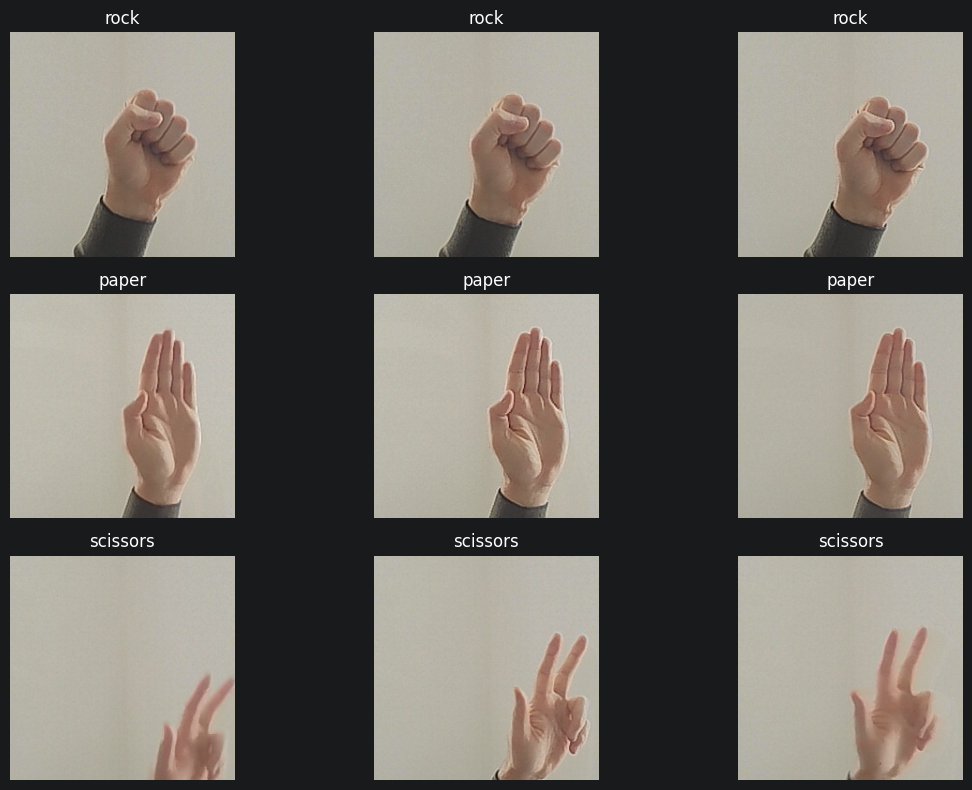

In [5]:
def show_sample_images(base_dir: Path, classes=("rock", "paper", "scissors"), n_per_class=3):
    plt.figure(figsize=(12, 8))
    plot_index = 1

    for cls in classes:
        cls_dir = base_dir / cls
        image_files = sorted([p for p in cls_dir.iterdir() if p.is_file()])[:n_per_class]

        for img_path in image_files:
            plt.subplot(len(classes), n_per_class, plot_index)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_DIR, n_per_class=3)

## 9. Build the data generators

We use `ImageDataGenerator` for:
- rescaling pixel values from `[0, 255]` to `[0, 1]`  
- simple image augmentation for the training set  

### Why augmentation?
Augmentation helps the model generalize better by creating slightly modified image versions, for example:
- rotation  
- zoom  
- shifting  
- horizontal flips  

This is especially useful for small or medium-sized image datasets.

In [6]:
IMG_SIZE = 150
BATCH_SIZE = 32

training_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = training_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)


Found 343 images belonging to 3 classes.
Found 157 images belonging to 3 classes.
Class mapping: {'paper': 0, 'rock': 1, 'scissors': 2}


## 10. Build the CNN model

This is a classic small CNN architecture:
- convolution layers extract visual patterns  
- max pooling reduces spatial size  
- dense layers perform the final classification  

The final layer has **3 output neurons** because we have 3 classes:
- rock  
- paper  
- scissors

In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Train the model

We now train the CNN on the training data and evaluate it on the test data after each epoch.

You can change the number of epochs depending on:
- your hardware  
- available time  
- how much overfitting you want to demonstrate in class

In [8]:
EPOCHS = 25

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.3003 - loss: 1.1195 - val_accuracy: 0.3057 - val_loss: 1.1001
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.2945 - loss: 1.1008 - val_accuracy: 0.3503 - val_loss: 1.0980
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.3236 - loss: 1.0999 - val_accuracy: 0.3503 - val_loss: 1.0946
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.3965 - loss: 1.0929 - val_accuracy: 0.4268 - val_loss: 1.0811
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - accuracy: 0.3907 - loss: 1.0808 - val_accuracy: 0.5414 - val_loss: 1.0410
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - accuracy: 0.4665 - loss: 1.0254 - val_accuracy: 0.3758 - val_loss: 1.1473
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.5102 - loss: 0.9961 - val_accuracy: 0.5732 - val_loss: 0.8658
Epoch 8/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - accuracy: 0.5306 - loss: 1.0007 - val_accuracy: 0.

## 12. Plot training history

These plots help you interpret the learning behavior:
- **Accuracy** shows how many examples are classified correctly  
- **Loss** shows how far predictions are from the true labels  

Look for:
- improving training accuracy  
- improving validation accuracy  
- overfitting if training improves but validation gets worse

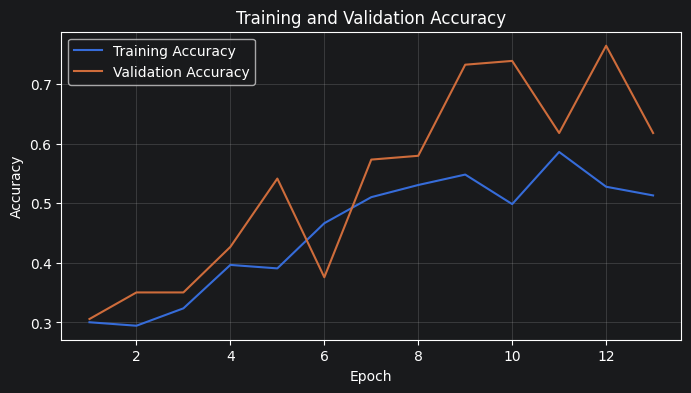

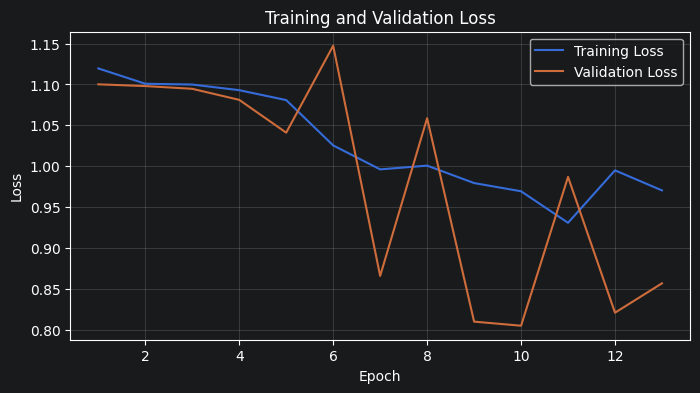

In [9]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Evaluate the model

Here we compute the final loss and accuracy on the test set.

In [10]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7389 - loss: 0.8049
Test loss: 0.8049
Test accuracy: 0.7389


## 14. Confusion matrix and classification report

This section gives a more detailed view of model performance:
- confusion matrix  
- precision  
- recall  
- F1-score  

That makes the notebook more useful for teaching and evaluation.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


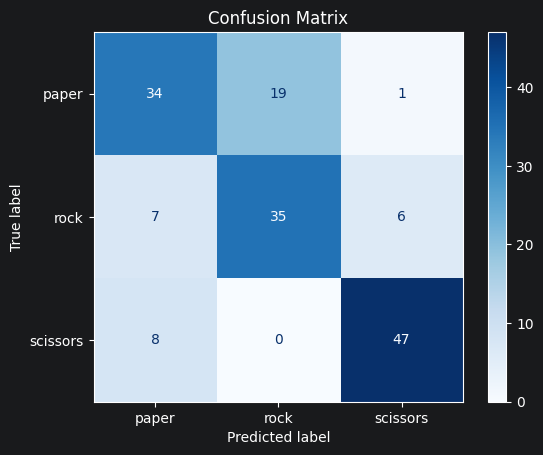

              precision    recall  f1-score   support

       paper       0.69      0.63      0.66        54
        rock       0.65      0.73      0.69        48
    scissors       0.87      0.85      0.86        55

    accuracy                           0.74       157
   macro avg       0.74      0.74      0.74       157
weighted avg       0.74      0.74      0.74       157



In [11]:
# Reset generator before prediction
test_generator.reset()

pred_probs = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

missing_predicted = [label for i, label in enumerate(class_labels) if np.sum(pred_classes == i) == 0]
if missing_predicted:
    print("Classes with no predicted samples:", missing_predicted)

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    zero_division=0
))

## 15. Save the trained model

Saving the model is useful when:
- you want to reuse it later  
- you do not want to retrain every time  
- you want to demonstrate loading and inference in a separate notebook

In [12]:
from project_config import MODEL_PATH

model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: C:\Users\b50578\OneDrive - FH CAMPUS 02\Documents\Campus02\LVs\Angewandtes machinelles Lernen\Übungen AML\Deep Learning\rps_cnn_model_base_early_stop_data_aug.keras


## 16. Reload the model

This demonstrates how to load a saved model from disk.

In [13]:
reloaded_model = tf.keras.models.load_model(MODEL_PATH)
reloaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,362,443 (39.53 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,908,296 (26.35 MB)

## 17. Predict on a single image

Use this section to test the model on one image manually.

Replace the path below with an actual image path from your dataset or a new image.

Example image: C:\Users\b50578\OneDrive - FH CAMPUS 02\Documents\Campus02\LVs\Angewandtes machinelles Lernen\Übungen AML\Deep Learning\Datasets\realdata\rps-test-set\rock\rock_20260413_150759_0000.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


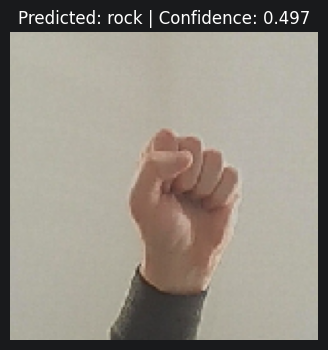

In [14]:
# Example: choose one image manually
example_image_path = next((TEST_DIR / "rock").glob("*"))
print("Example image:", example_image_path)

img = load_img(example_image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = reloaded_model.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]
confidence = float(np.max(prediction))

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} | Confidence: {confidence:.3f}")
plt.axis("off")
plt.show()

## 18. Notes for troubleshooting

### If TensorFlow does not install
Use Python **3.11** and make sure the environment is activated before installing.

### If Jupyter uses the wrong kernel
Switch the kernel to:
**Python (rps-cnn)**

### If the generator finds 0 images
Check:
- folder names  
- ZIP extraction  
- whether the images are really inside `rock`, `paper`, and `scissors` subfolders  

### If your folders are named differently
Adjust:
- `TRAIN_DIR`
- `TEST_DIR`

### If you already have a separate validation folder
You can replace `TEST_DIR` with your validation folder or add a third generator.

## 19. Optional extensions for students

Possible follow-up tasks:
1. Change the CNN architecture and compare results  
2. Increase or decrease augmentation  
3. Compare training with and without dropout  
4. Add early stopping  
5. Try grayscale images  
6. Test the model on their own webcam or smartphone images